# 16 — TBM-X Uncertainty Quantification

Monte Carlo ile giriş belirsizliklerinin performansa etkisini inceleyen kavramsal analiz..

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)
OUT = Path('outputs/uq'); OUT.mkdir(parents=True, exist_ok=True)
nominal = {'MTOW_kg':3400, 'wing_area_m2':18, 'AR':9.15, 'power_kW':650, 'cruise_speed_kt':300, 'cd0':0.025, 'e':0.80, 'prop_eff':0.85}
N = 20000
samples = pd.DataFrame({k:RNG.normal(v, abs(v)*0.03, N) for k,v in nominal.items()})
samples['cd0'] = samples['cd0'].clip(.01,.06)
samples['e'] = samples['e'].clip(.6,.95)
samples['prop_eff'] = samples['prop_eff'].clip(.65,.95)

In [2]:
RHO=0.38; G=9.80665; KTMS=.514444
W=samples.MTOW_kg*G; V=samples.cruise_speed_kt*KTMS; q=.5*RHO*V**2
CL=W/(q*samples.wing_area_m2); k=1/(np.pi*samples.AR*samples.e); CD=samples.cd0+k*CL**2
drag=q*samples.wing_area_m2*CD
req=drag*V/(samples.prop_eff*1000)
roc=(samples.power_kW*1000-req*1000)/W*3.28084*60
results=samples.assign(CL=CL,CD=CD,L_D=CL/CD,required_power_kW=req,power_margin_kW=samples.power_kW-req,ROC_ft_min=roc)
results.describe()

,MTOW_kg,wing_area_m2,AR,power_kW,cruise_speed_kt,cd0,e,prop_eff,CL,CD,L_D,required_power_kW,power_margin_kW,ROC_ft_min
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,3400.515195,18.002040,9.146581,649.910960,299.883247,0.024999,0.800061,0.849932,0.411149,0.032406,12.678172,479.210188,170.700772,1009.725455
std,102.482495,0.542348,0.273800,19.593255,9.064415,0.000753,0.024158,0.025483,0.030554,0.001371,0.603948,37.396153,42.011451,255.048190
min,2952.310312,15.701215,8.077587,574.181229,265.584485,0.022141,0.684425,0.753769,0.301065,0.027828,10.189522,353.631705,-3.346124,-19.526729
25%,3331.649728,17.638077,8.964184,636.768921,293.728589,0.024493,0.783799,0.832725,0.389951,0.031467,12.269088,453.060638,142.938395,840.448743
50%,3399.825199,18.000940,9.145427,649.686249,299.853553,0.024993,0.800065,0.850019,0.409727,0.032331,12.681301,477.705496,171.981177,1013.140431
75%,3468.622274,18.365114,9.329163,663.121976,306.044999,0.025504,0.816295,0.867240,0.430740,0.033278,13.084279,503.397878,199.219257,1182.085825
max,3823.426622,20.336537,10.524486,728.552764,340.560712,0.028034,0.910042,0.950000,0.562858,0.039809,15.186356,657.849487,329.962423,1906.510354


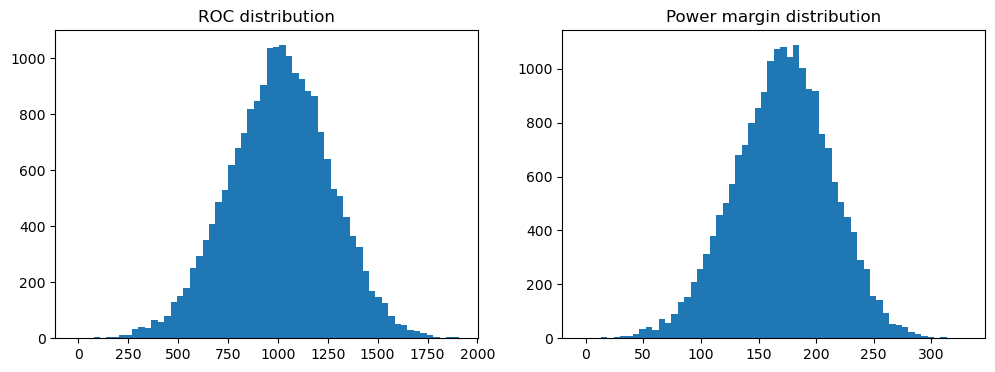

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].hist(results.ROC_ft_min,bins=60); ax[0].set_title('ROC distribution'); ax[1].hist(results.power_margin_kW,bins=60); ax[1].set_title('Power margin distribution'); plt.show()
quantiles=results[['ROC_ft_min','power_margin_kW','L_D']].quantile([.05,.5,.95]); quantiles
results.to_csv(OUT/'uq_monte_carlo_results.csv',index=False); quantiles.to_csv(OUT/'uq_quantiles.csv')